# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


Observaciones:
    - No se observan nulos en las respectivas columnas del dataset
    - La columna date es de tipo de dato object y debería de ser datetime
- El proximo paso a seguir para esta columna es hacer la respectiva transformación del tipo de dato de object a date
    - El dataset no tiene valores ausentes.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
#Se verifican si hay usuarios unicos con esta función a traves de ver los usuarios repetidos
df['user_id'].duplicated().sum()

0

 **Variable `date`**  
Explorar rango de fechas

In [6]:
#Transformación de columna date de object a date time
df['date'] = pd.to_datetime(df['date'])
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1].describe()


,converted,gasto
count,5706.0,5706.000000
mean,1.0,65.373668
std,0.0,30.896545
min,1.0,12.120000
25%,1.0,42.950000
50%,1.0,59.860000
75%,1.0,80.370000
max,1.0,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen para 
columnas=['landing','region','traffic_source','user_type']

for col in columnas:
    print("\nConteo de categorías:",col)
    print(df[col].value_counts())   



Conteo de categorías: landing
B    20018
A    19982
Name: landing, dtype: int64

Conteo de categorías: region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Conteo de categorías: traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Conteo de categorías: user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


**Observaciones:**
    - Todas las columnas tienen valores esperados.
    - Los valores no presentan nada extraño.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['converted']==1)&(df['landing']=='A')]['gasto']
gasto_B = df[(df['converted']==1)&(df['landing']=='B')]['gasto']
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [12]:

promedio_gasto_A=gasto_A.mean()
promedio_gasto_B=gasto_B.mean()
print("El promedio del gasto A es:",promedio_gasto_A)
print("El promedio del gasto B es:",promedio_gasto_B)


El promedio del gasto A es: 61.0865724522293
El promedio del gasto B es: 68.74536005009392


### Prueba t de Student

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia significativa  entre el gasto promedio entre usuarios de las páginas A y B
- **Hipótesis alternativa (H₁):** Hay diferencia significativa entre el gasto promedio entre usuarios de las páginas A y B

In [17]:
#Prueba de Levene para verificar si cumple con varianzas iguales para aplicar la prueba t de student
l_stat,p_value_bar=levene(gasto_A,gasto_B)
print(f"Estadístico : {l_stat}")
print(f"Valor p: {p_value_bar}")

Estadístico : 29.17646453202917
Valor p: 6.875301988016449e-08


In [18]:
# Aplicar prueba

t_stat,p_value=ttest_ind(gasto_A,gasto_B,equal_var=False)



# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [31]:
alpha=0.05

if p_value>alpha:
    print("No se rechaza la hipótesis nula")

else:
    print("Se rechaza la hpótesis nula")

Se rechaza la hpótesis nula


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Hay una diferencia significativa en los gastos realizados de los usuarios entre las páginas A y B. Evidencia de ello, se encuentra en el valor p que presenta un valor de 6.8753e-08, siendo este muy cercano a 0. Además, en los cálculos de los gastos promedio, se observa que el gasto B es de 68.7454 a diferencia del gasto A que es de 61.08657


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z test

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión entre las páginas A y B es igual. Cualquier diferencia se debe al azar
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre las páginas A y B

In [32]:
# Número de usuarios convertidos por página
conversiones=df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales=df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [33]:
exitos=[conversiones['A'],conversiones['B']]
observaciones=[totales['A'],totales['B']]

In [34]:
# Aplicar prueba
z_stat,p_value=proportions_ztest(exitos,observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [35]:
# Interpretar resultados
alpha=0.05

if p_value>alpha:
    print("No se rechaza la hipótesis nula")

else:
    print("Se rechaza la hpótesis nula")

Se rechaza la hpótesis nula


In [36]:
# Comparar tasas de éxito
tasa_A=exitos[0]/observaciones[0]
tasa_B=exitos[1]/observaciones[1]
print(f"Tasa de conversión de la página A:{tasa_A:.2%}")
print(f"Tasa de conversión de la página B:{tasa_B:.2%}")
#Interpretación de los resultados
if tasa_A > tasa_B:
    print(f"\n La página A tiene una mayor tasa de conversión({tasa_A-tasa_B:.2%})")
    
elif tasa_B>tasa_A:
    print(f"\n La página B tiene una mayor tasa de conversión({tasa_B-tasa_A:.2%})")

else:
    print("\n Ambas páginas tienen la misma tasa de conversión")
    

Tasa de conversión de la página A:12.57%
Tasa de conversión de la página B:15.96%

 La página B tiene una mayor tasa de conversión(3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
La tasa de conversión entre los grupos A y B es diferente, ya que la prueba estadística que confirma esto arroja un valor p de 3.7630e-22 siendo muy bajo este valor y muy cercano a 0. Adicionalmente, la tasa de conversión de la página b es de 15.96% siendo esta mayor a la de la página A la cual es de 12.57%

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ z-test de proporciones correcto, con conclusión coherente con el resultado.
</div>

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables de fuente de tráfico y la conversión. Es decir, son independientes
- **Hipótesis alternativa (H₁):** Si existe una relación entre las variables de fuente de tráfico y la conversión. Es decir, no son independientes.

In [39]:
tabla_traffic=pd.crosstab(df['traffic_source'],df['converted'])
tabla_traffic

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [40]:
# Aplicar prueba
chi2_stat,p_value,dof,expected=chi2_contingency(tabla_traffic)

print("El estadístico Chi-cuadrado es:",chi2_stat)
print("El valor p es:",p_value)
print("Los grados de libertad son",dof)
print("Las frecuencias esperadas son:")
print(expected)

El estadístico Chi-cuadrado es: 8.662108841397938
El valor p es: 0.0341375947833914
Los grados de libertad son 3
Las frecuencias esperadas son:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [41]:
#Proporciones por tráfico
proporcion= (tabla_traffic[1]/(tabla_traffic[0]+tabla_traffic[1]))*100.0
proporcion

traffic_source
Ads         14.738165
Email       14.992651
Organic     13.787736
Referral    13.881163
dtype: float64

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Se demuestra que hay relación entre las variables de fuente de tráfico y conversión. Evidencia de ello esta en el valor p que presentó un valor de 0.034, siendo este significativo por ser menor del sugerido que es de 0.05. Agregando que el trafico de recurso que presento una conversión mas alta fue el de Email con una tasa de 14.99% y con la tasa más baja de organico de 13.79%.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Chi-cuadrado correcto.
</div>

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las variables de tipo de usuario y conversión.Es decir, son independientes
- **Hipótesis alternativa (H₁):** Existe relación entre las variables de tipo de usuario y conversión. Es decir, no son independientes

In [42]:
tabla_user_type=pd.crosstab(df['user_type'],df['converted'])
tabla_user_type

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [43]:
# Aplicar prueba
chi2_stat,p_value,dof,expected=chi2_contingency(tabla_user_type)

print("El estadístico Chi-cuadrado es:",chi2_stat)
print("El valor p es:",p_value)
print("Los grados de libertad son",dof)
print("Las frecuencias esperadas son:")
print(expected)


El estadístico Chi-cuadrado es: 0.5134849494478645
El valor p es: 0.4736341272301974
Los grados de libertad son 1
Las frecuencias esperadas son:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [44]:
#Proporciones por user_type
proporcion= (tabla_user_type[1]/(tabla_user_type[0]+tabla_user_type[1]))*100.0
proporcion

user_type
Nuevo         14.358699
Recurrente    14.090356
dtype: float64

### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Se demuestra que no hay relación entre las variables de tipo de usuario y conversión. Esto se soporta en el valor p, el cual arroja un valor de 0.474, el cuál es mayor del requerido para rechazar la hipótesis nula(0.05), también se observan las proporciones entre los tipos de usuario, siendo estas muy similares, con usuario nuevo con tasa de conversión de 14.36% y usuario recurrente de 14.09%

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

✅ Chi-cuadrado correcto también acá.
</div>

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

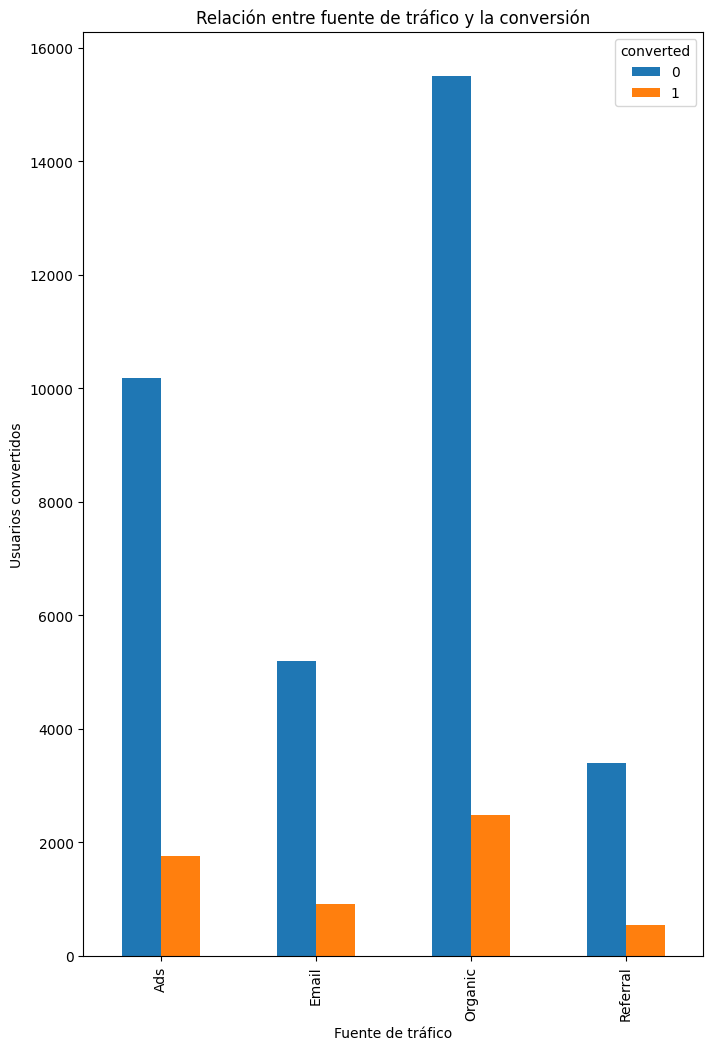

In [45]:
tabla_traffic.plot(kind='bar',figsize=(8,12))

plt.title('Relación entre fuente de tráfico y la conversión')
plt.ylabel('Usuarios convertidos',fontsize=10)
plt.xlabel('Fuente de tráfico',fontsize=10)
plt.show()


✍️ **Observaciones**: 
- En el ***gráfico absoluto***, se observa que hay mas usuarios que no se convirtieron, respecto a los que si se convirtieron, siendo este patrón común en todas las fuentes de tráfico. Adicionalmente, en la que hay mayor diferencia entre usuarios convertidos y no es en el tipo de fuente de tráfico orgánica.

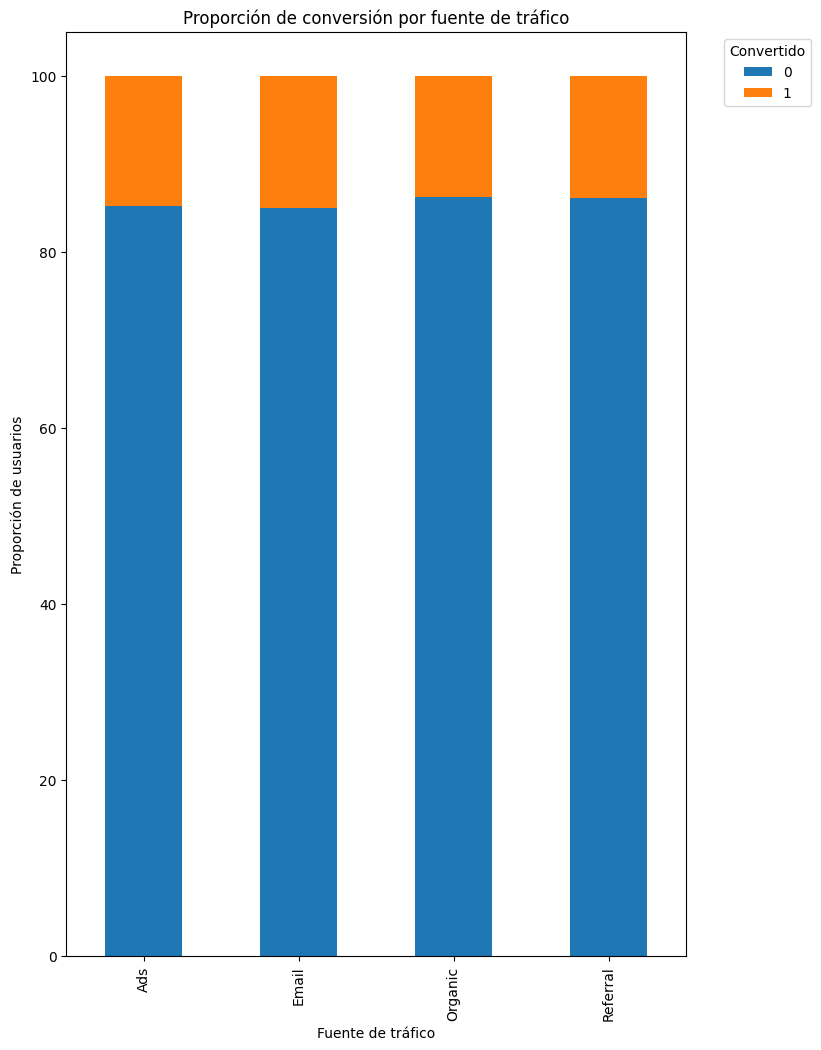

In [46]:
#Tabla de proporciones de usuarios
traffic_normalizado=pd.crosstab(df['traffic_source'],df['converted'],normalize='index')*100.0

#Gráfico de barras apiladas
traffic_normalizado.plot(kind='bar',stacked=True,figsize=(8,12))
#Títulos de gráfico y ejes
plt.title('Proporción de conversión por fuente de tráfico',fontsize=12)
plt.ylabel('Proporción de usuarios',fontsize=10)
plt.xlabel('Fuente de tráfico',fontsize=10)
plt.legend(title='Convertido', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

***Observaciones***:
- En el ***gráfico relativo***,las conversiones presentan proporciones con diferencias sutiles entre las conversiones y el tipo de fuente de tráfico. Estas diferencias sutiles, se soportan en el valor p, que es de 0.034, que a pesar de ser significativo esta cercano al límite del valor mínimo aceptable que es de 0.05

### Relación entre el tipo de usuario y la conversión

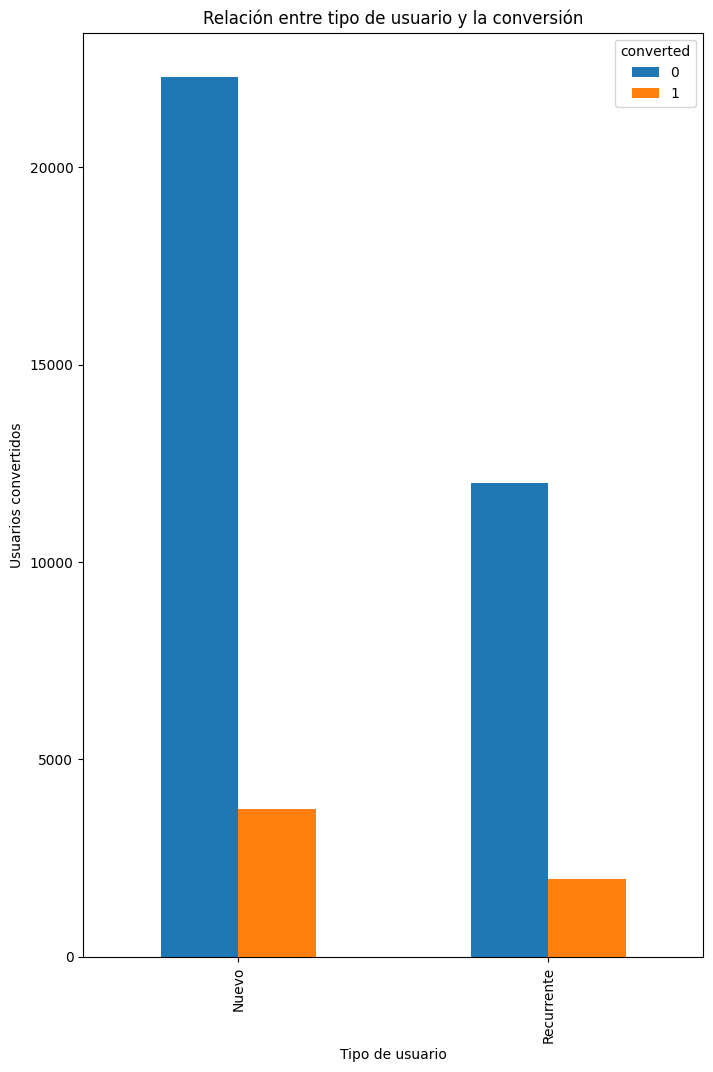

In [47]:
tabla_user_type.plot(kind='bar',figsize=(8,12))

plt.title('Relación entre tipo de usuario y la conversión')
plt.ylabel('Usuarios convertidos',fontsize=10)
plt.xlabel('Tipo de usuario',fontsize=10)
plt.show()

**Observaciones**: 
- En el ***gráfico absoluto** se observa una mayor cantidad de usuarios que no se convirtieron tanto en nuevos como en recurrentes.


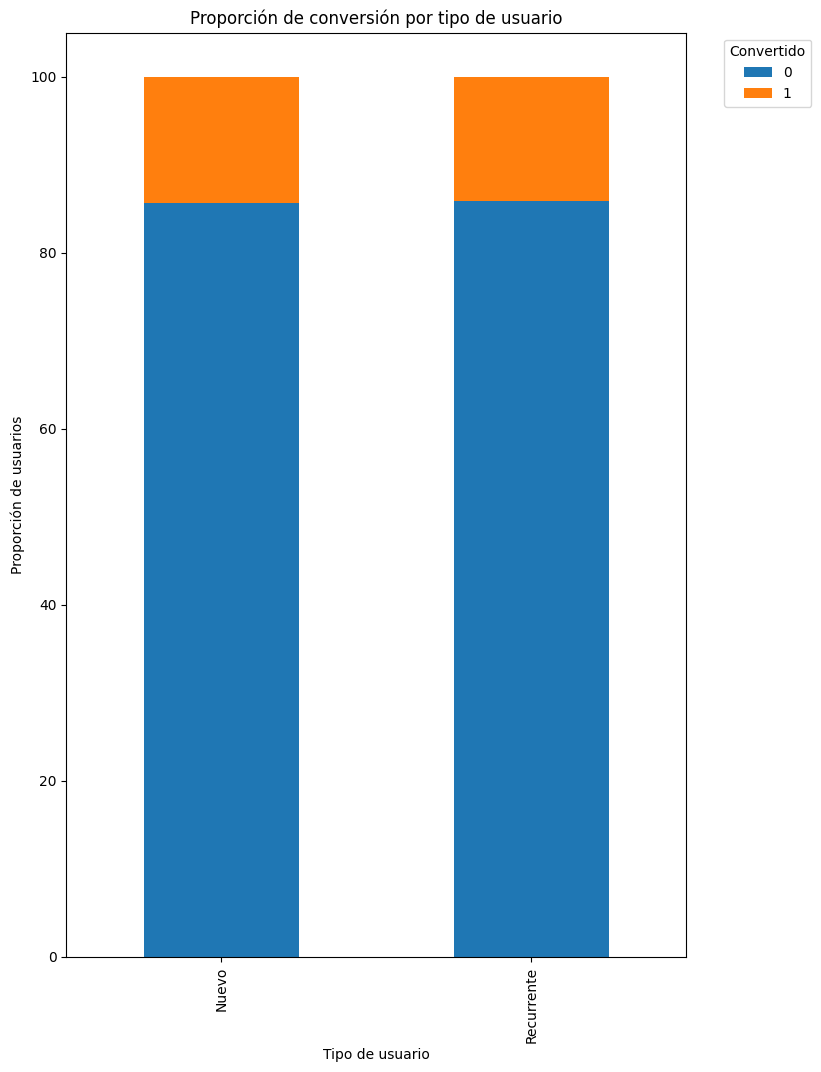

In [50]:
#Normalizar tabla de tipo de usuario
user_type_normalizado=pd.crosstab(df['user_type'],df['converted'],normalize='index')*100.0

#Gráfico de tipo de usuario
user_type_normalizado.plot(kind='bar',stacked=True,figsize=(8,12))
plt.title('Proporción de conversión por tipo de usuario',fontsize=12)
plt.ylabel('Proporción de usuarios',fontsize=10)
plt.xlabel('Tipo de usuario',fontsize=10)
plt.legend(title='Convertido', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Gráfico de conversión/gasto por landing

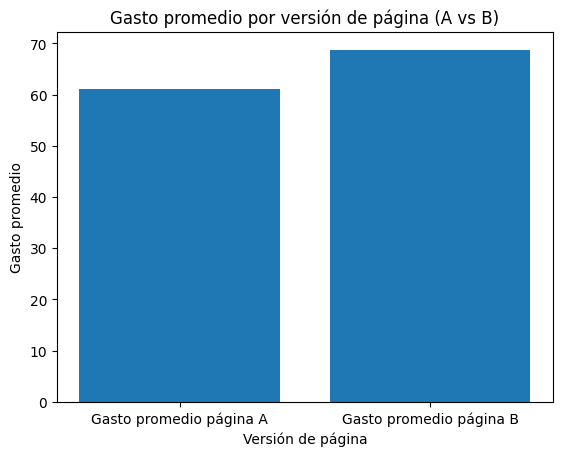

In [22]:
#Creación de gráfico conversión/gasto por landing (A vs B)
plt.bar(["Gasto promedio página A", "Gasto promedio página B"], [promedio_gasto_A, promedio_gasto_B])

plt.title("Gasto promedio por versión de página (A vs B)",fontsize=12)
plt.ylabel("Gasto promedio",fontsize=10)
plt.xlabel("Versión de página",fontsize=10)
plt.show()



***Observaciones***:

-Se observa mayor conversión/gasto en la página B que en la página A

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
-Página A: 61.0865
-Página B: 68.7453
- **Interpretación:**
Hay una diferencia entre el gasto promedio entre las páginas A y B, siendo la página B con mayor gasto promedio por usuarios. Además, estas diferencias son confiables porque  el valor p fue de 6.8753e-08, siendo este valor muy cercano a 0
<br>

**Tasa de conversión:** 
- Tasa de conversión de la página A:12.57%
- Tasa de conversión de la página B:15.96%
- **Interpretación:**
La página B tiene una mayor tasa de conversión con una diferencia de 3.38%. Estas diferencias son estadisticamente confiables por presentar el valor p de 3.7630e-22
---

#### 📊 **Segmentación por fuente de tráfico**
- Las fuentes de tráfico presentaron las siguientes proporciones:
-Email:14.99%                                                                                                                                                                                              -Anuncios: 14.74%                                                                                                                                                                                          -Referido: 13.88%                                                                                                                                                                                          -Orgánico: 13.79%
- **Interpretación:**
La fuente con mayor tasa de conversión fue por vía email, mientras que la fuente con menor tasa de conversión de tráfico fue vía orgánico. Estas diferencias son estadisticamente significativas por presentar un valor p de 0.034, siendo este valor menor que 0.05 que es el minímo requerido para que una prueba estadística sea significativa.
 ---

#### 📊 **Segmentación por tipo de usuario**
- Nuevo: 14.36%
- Recurrente: 14.09%
- **Interpretación:**
Las diferencias entre tipos de usuarios presentaron leves variaciones, que se pueden deber al azar, siendo esto soportado por el valor p de 0.474, el cual es mayor que el mínimo de 0.05
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Utilizar con mayor fuerza la página B, ya que presentan mayores gastos promedio y tasas de conversión.
- Hacer mayor inversión a la fuente de tráfico de email, ya que presentó mayores proporciones y los resultados del estadstico fueron significativos